In [1]:
library(data.table)
library(stringr)

In [2]:
test = data.frame(fread('./input/ALL-5e-8-from-5-paper.ma'))

In [3]:
df_all = data.frame()
for (ct in c('CD14Mono', 'CD16Mono', 'cDC', 'pDC','CD4T','CD8T', 'NK','T_Prolif', 'B', 'Plasma')) {
    df = data.frame(fread(paste0("./res/combine-All/",ct,"_cis_fdr005.csv")))
    df$eqtl = paste0(df$snps,'_',df$gene)
    df$ct = ct
    df = df[df$snps %in% test$SNP,]
    df_all = rbind(df_all,df)
    }

In [4]:
library(ggplot2)
library(dplyr)
library(RColorBrewer)
library("data.table")
library(stringr)

Warning message:
“程辑包‘ggplot2’是用R版本4.1.3 来建造的”

载入程辑包：‘dplyr’


The following objects are masked from ‘package:data.table’:

    between, first, last


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Warning message:
“程辑包‘RColorBrewer’是用R版本4.1.3 来建造的”


In [5]:
gg.manhattan <- function(
    df, threshold, sig, sugg, hlight,
    col, ylims, title, s_col,
    genome = "hg38"
){

    options(repr.plot.width = 20, repr.plot.height = 4)

    library(dplyr)
    library(ggplot2)

    #--------------------------------------------------
    # 1. 染色体真实长度
    #--------------------------------------------------
    if (genome == "hg38") {

        chr_len <- c(
            248956422, 242193529, 198295559, 190214555,
            181538259, 170805979, 159345973, 145138636,
            138394717, 133797422, 135086622, 133275309,
            114364328, 107043718, 101991189, 90338345,
            83257441, 80373285, 58617616, 64444167,
            46709983, 50818468
        )

    } else if (genome == "hg19") {

        chr_len <- c(
            249250621, 243199373, 198022430, 191154276,
            180915260, 171115067, 159138663, 146364022,
            141213431, 135534747, 135006516, 133851895,
            115169878, 107349540, 102531392, 90354753,
            81195210, 78077248, 59128983, 63025520,
            48129895, 51304566
        )

    } else {
        stop("genome 只能为 'hg38' 或 'hg19'")
    }


    chr_info <- data.frame(
        chr = 1:22,
        chr_len = chr_len
    ) %>%
        mutate(
            tot = cumsum(chr_len) - chr_len,
            start = tot,
            end = tot + chr_len,
            center = tot + chr_len / 2
        )

    df.tmp <- df %>%

        mutate(
            chr = as.numeric(
                gsub("^chr", "", as.character(chr))
            )
        ) %>%

        filter(chr %in% 1:22) %>%

        left_join(
            chr_info %>% select(chr, tot),
            by = "chr"
        ) %>%

        arrange(chr, pos) %>%

        mutate(
            BPcum = pos + tot,
            is_highlight = ifelse(
                SNP %in% hlight,
                "yes",
                "no"
            ),
            is_annotate = ifelse(
                P < threshold,
                "yes",
                "no"
            ),
            chr_factor = factor(
                chr,
                levels = 1:22
            )
        )


    chr_colors <- rep(
        col,
        length.out = 22
    )

    names(chr_colors) <- as.character(1:22)


    p <- ggplot(
        df.tmp,
        aes(
            x = BPcum,
            y = -log10(P)
        )
    ) +

        # 所有 SNP
        geom_point(
            aes(color = chr_factor),
            alpha = 0.8,
            size = 2
        ) +

        # 显著 SNP
        geom_point(
            data = df.tmp %>% filter(P < sig),
            aes(
                x = BPcum,
                y = -log10(P)
            ),
            color = s_col,
            size = 3
        ) +

        # 染色体颜色
        scale_color_manual(
            values = chr_colors,
            breaks = as.character(1:22),
            drop = FALSE
        ) +

        #--------------------------------------------------
        # 强制完整显示 chr1-22
        #--------------------------------------------------
        scale_x_continuous(
            breaks = chr_info$center,
            labels = chr_info$chr,
            limits = c(
                0,
                max(chr_info$end)
            ),
            expand = c(0, 0)
        ) +

        scale_y_continuous(
            expand = c(0, 0),
            limits = ylims
        ) +

        # genome-wide significance
        geom_hline(
            yintercept = -log10(sig)
        ) +

        # suggestive significance
        #geom_hline(
       #     yintercept = -log10(sugg),
        #    linetype = "dashed"
       # ) +

        ggtitle(title) +

        labs(
            x = "",
            y = "-log10(P)"
        ) +

        theme_bw(
            base_size = 22
        ) +

        theme(aspect.ratio = 0.21,
            panel.grid = element_blank(),
            plot.title = element_text(
                hjust = 0.5
            ),
            legend.position = "none",
            axis.text = element_text(
                size = 20
            ),
            axis.title = element_text(
                size = 20
            )
        )

    return(p)
}

In [6]:
color = c('#FFDAB9','#CD6600', '#8B4500', '#FF8C00','#3D83C5','#A2D8E5','#917FBA','#696969','#F1A1C2','#E7211A')
cts =  c('CD14Mono', 'CD16Mono', 'cDC', 'pDC','CD4T','CD8T', 'NK','T_Prolif', 'B', 'Plasma')
names(color) <- cts

[1] "CD14Mono"
[1] "CD16Mono"


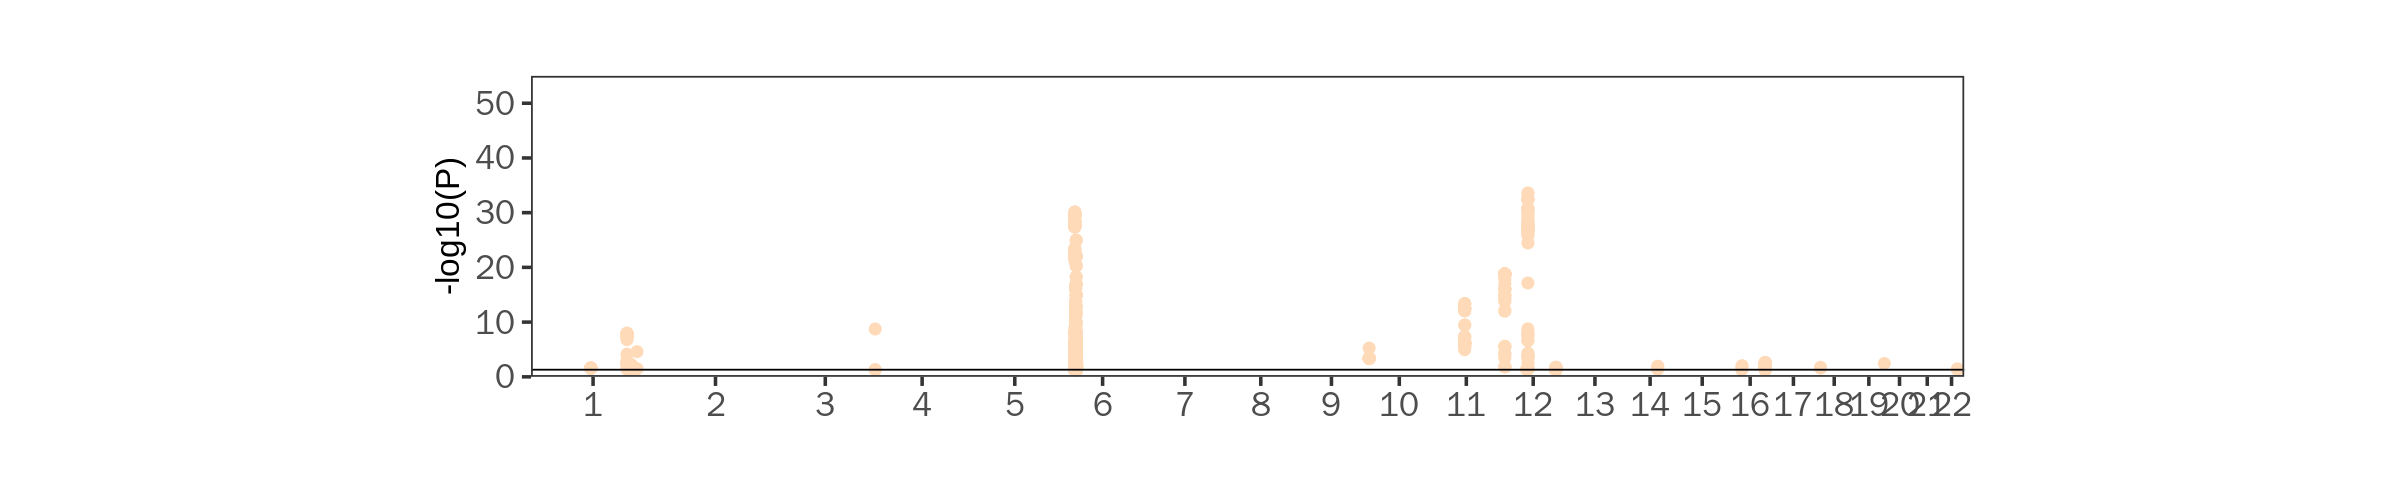

[1] "cDC"


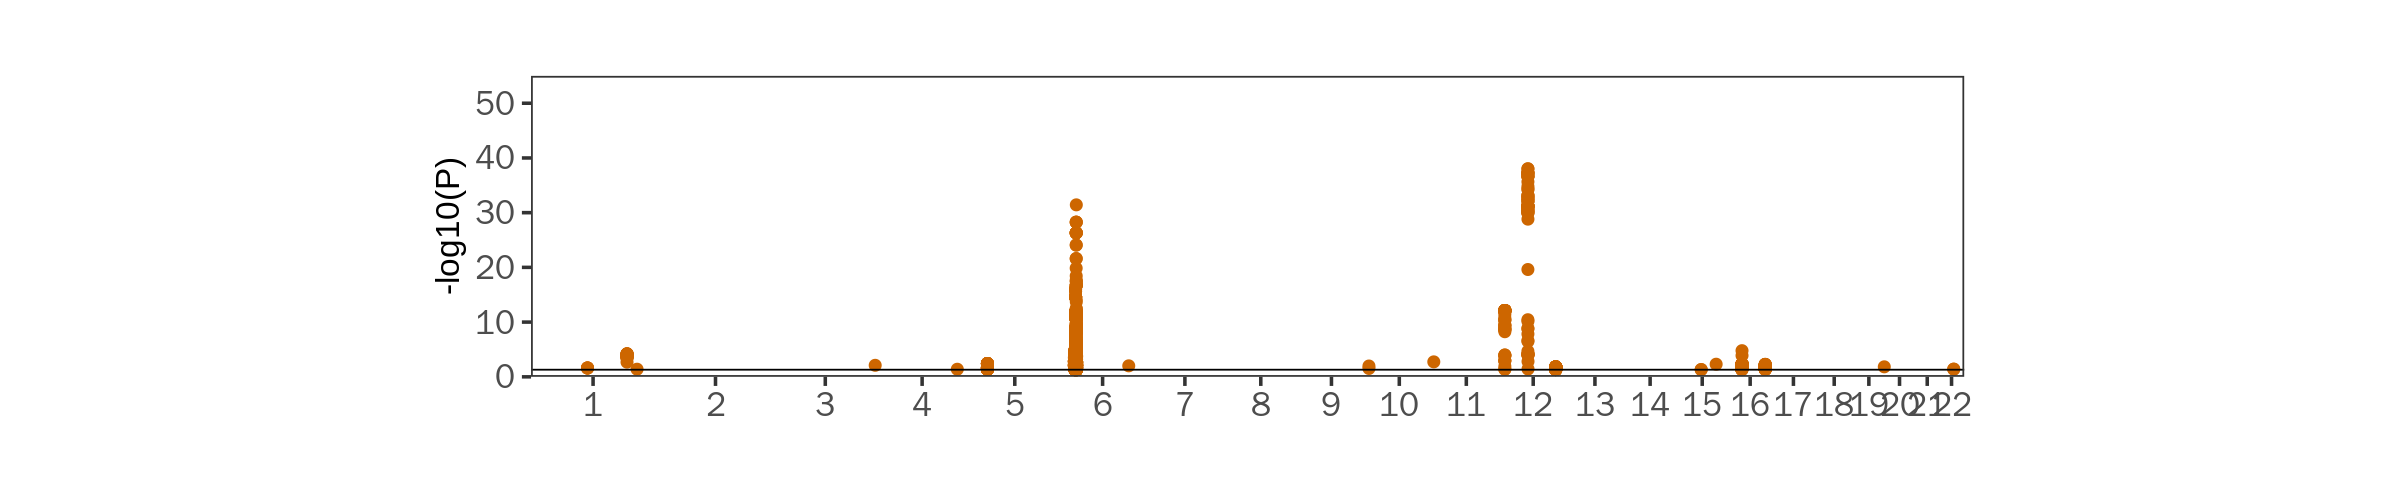

[1] "pDC"


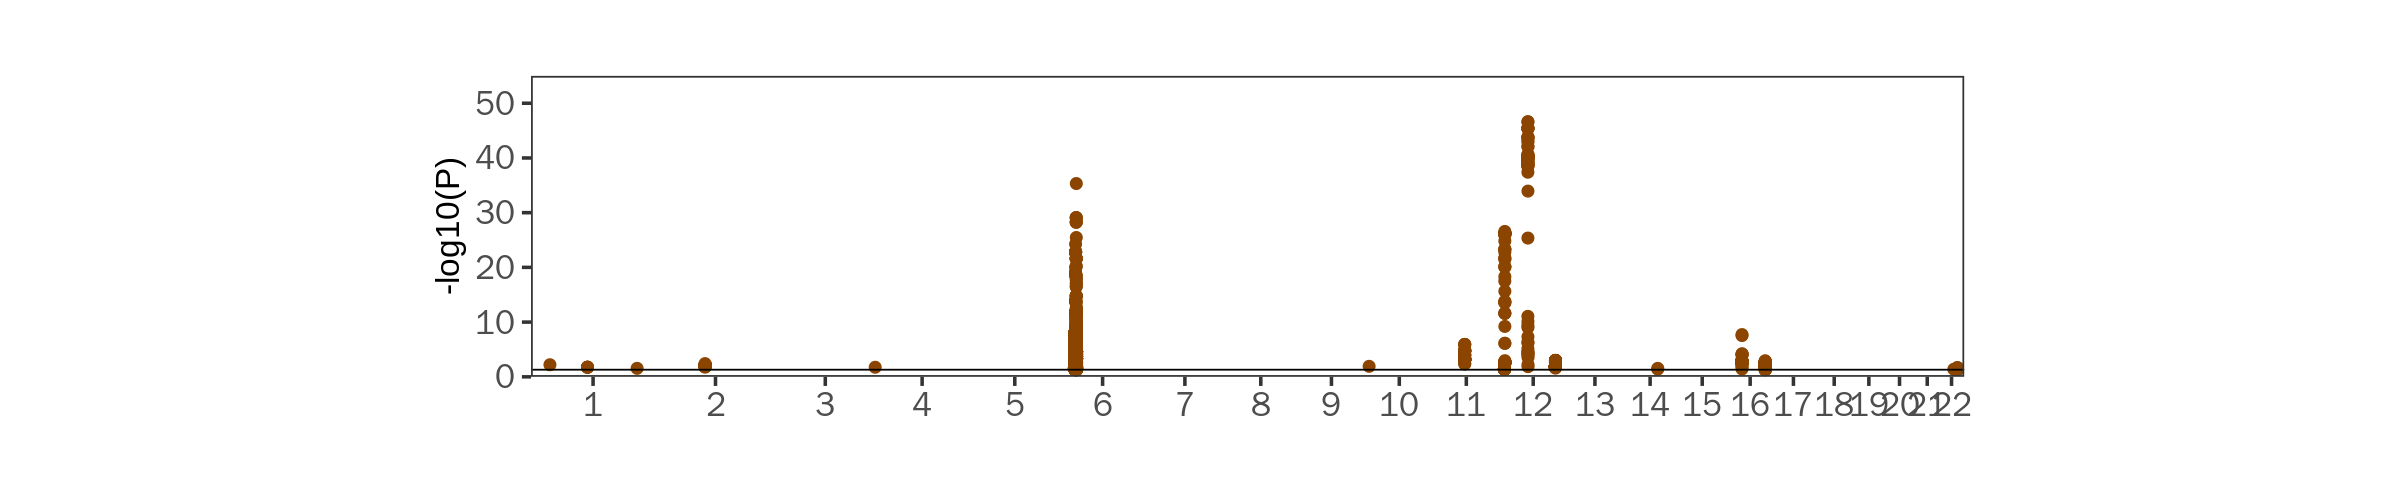

[1] "CD4T"


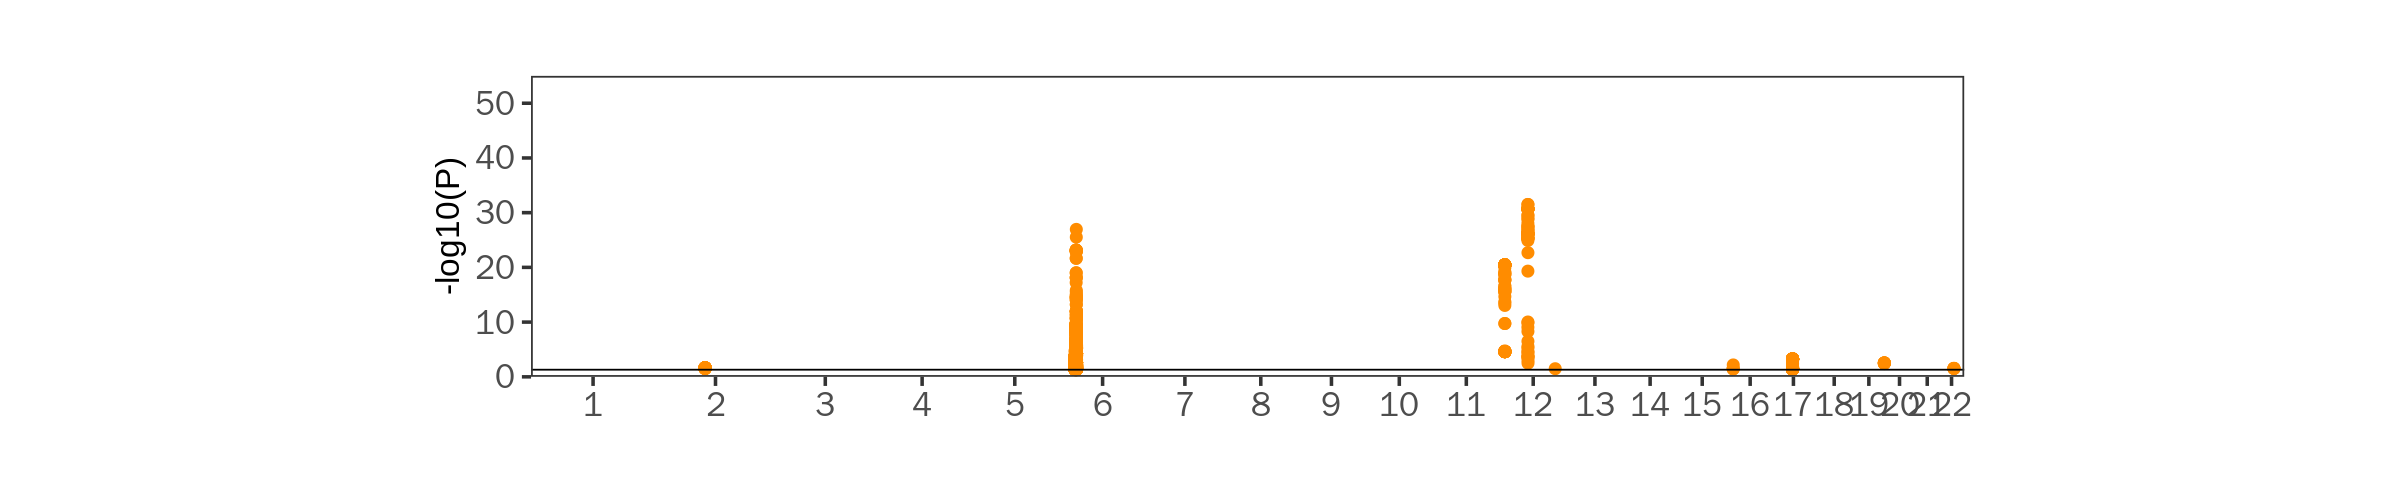

[1] "CD8T"


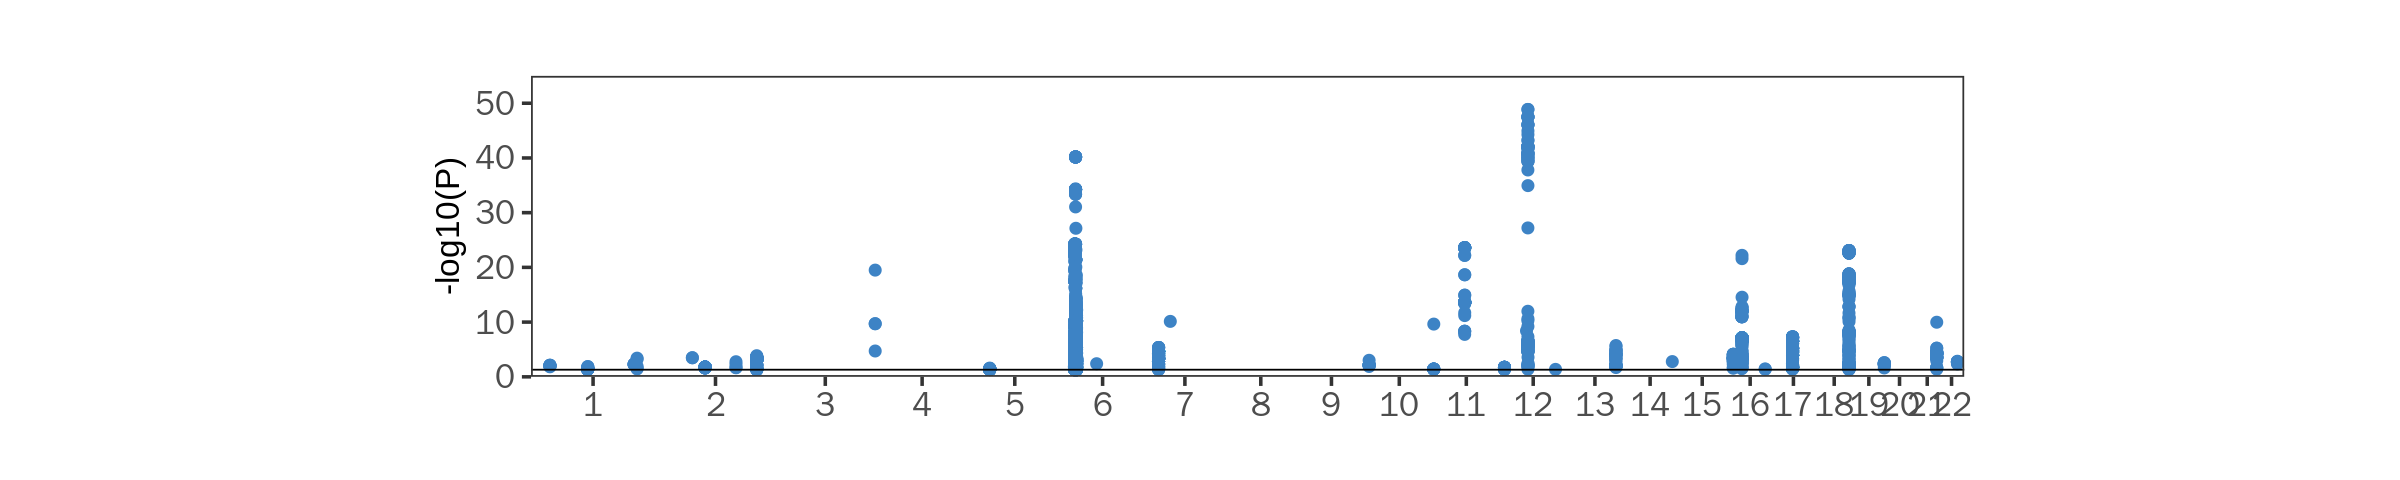

[1] "NK"


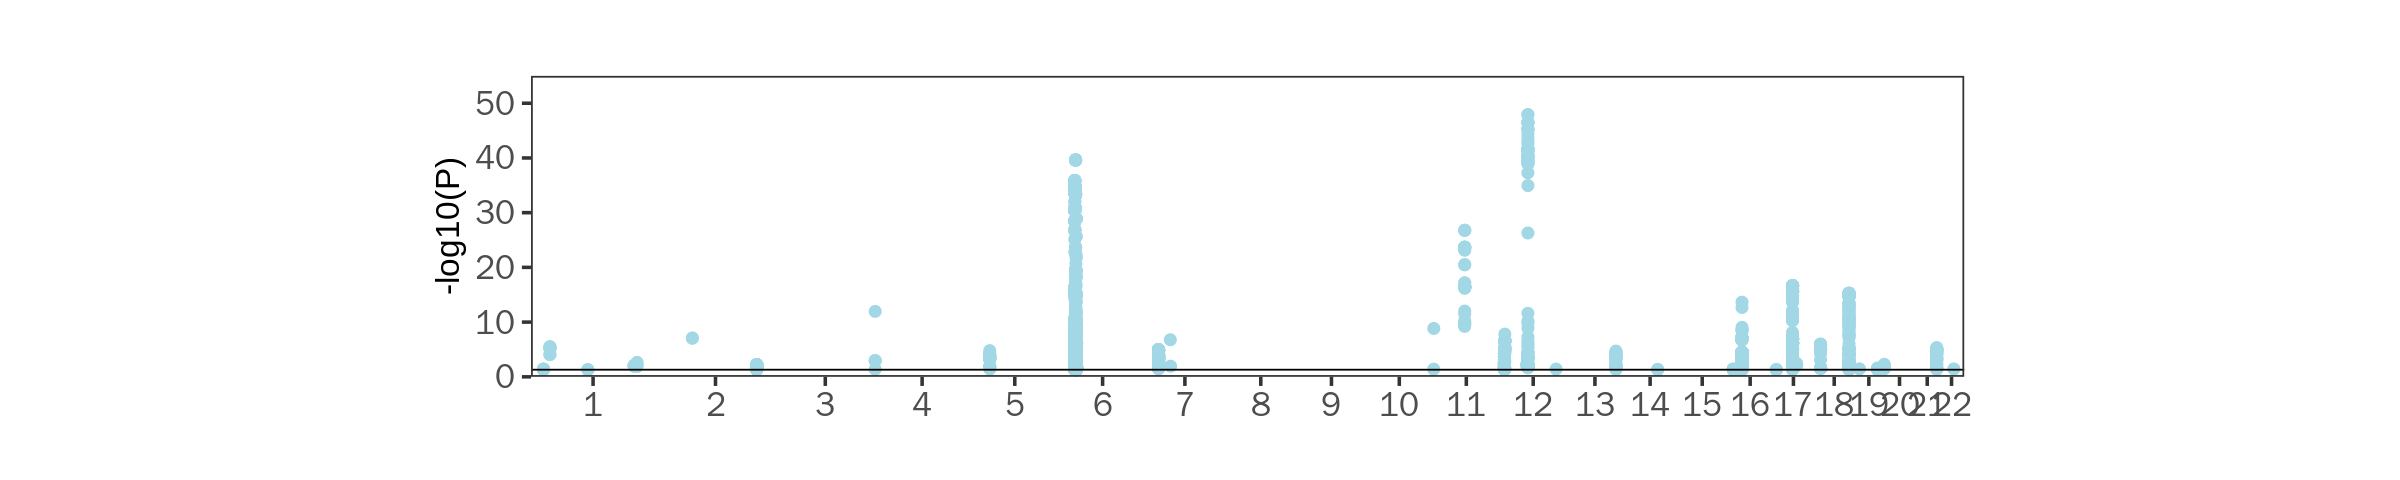

[1] "T_Prolif"


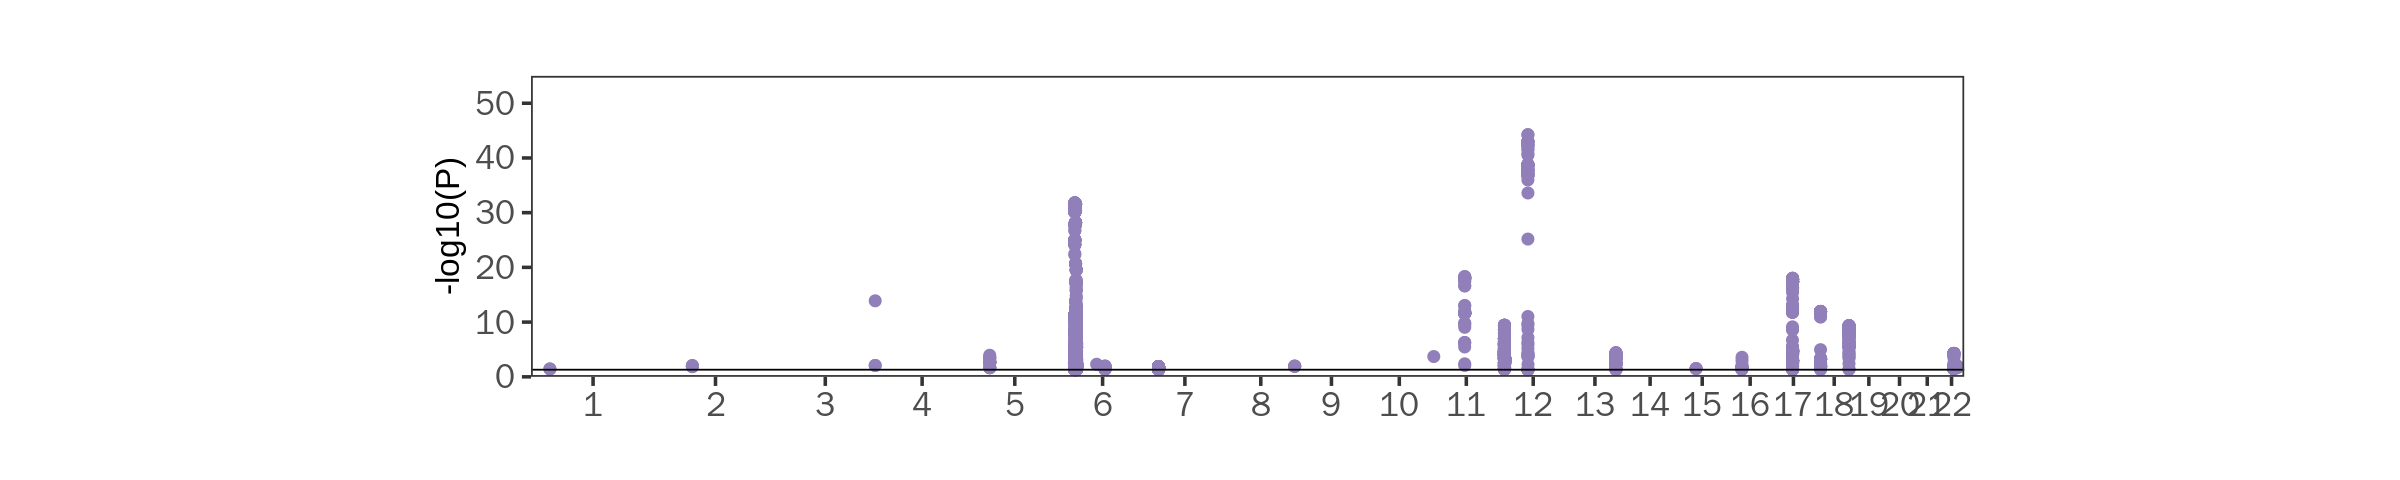

[1] "B"


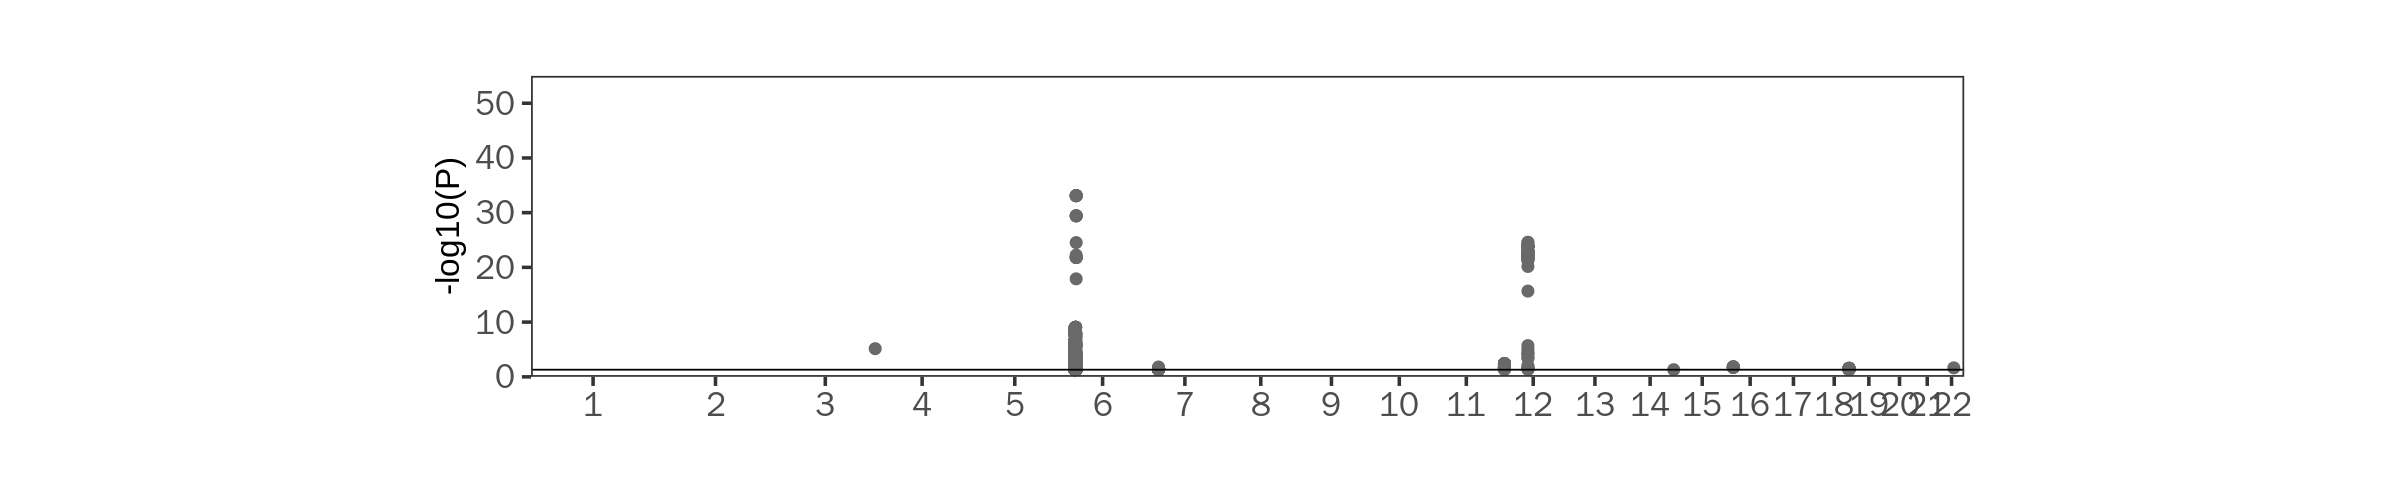

[1] "Plasma"


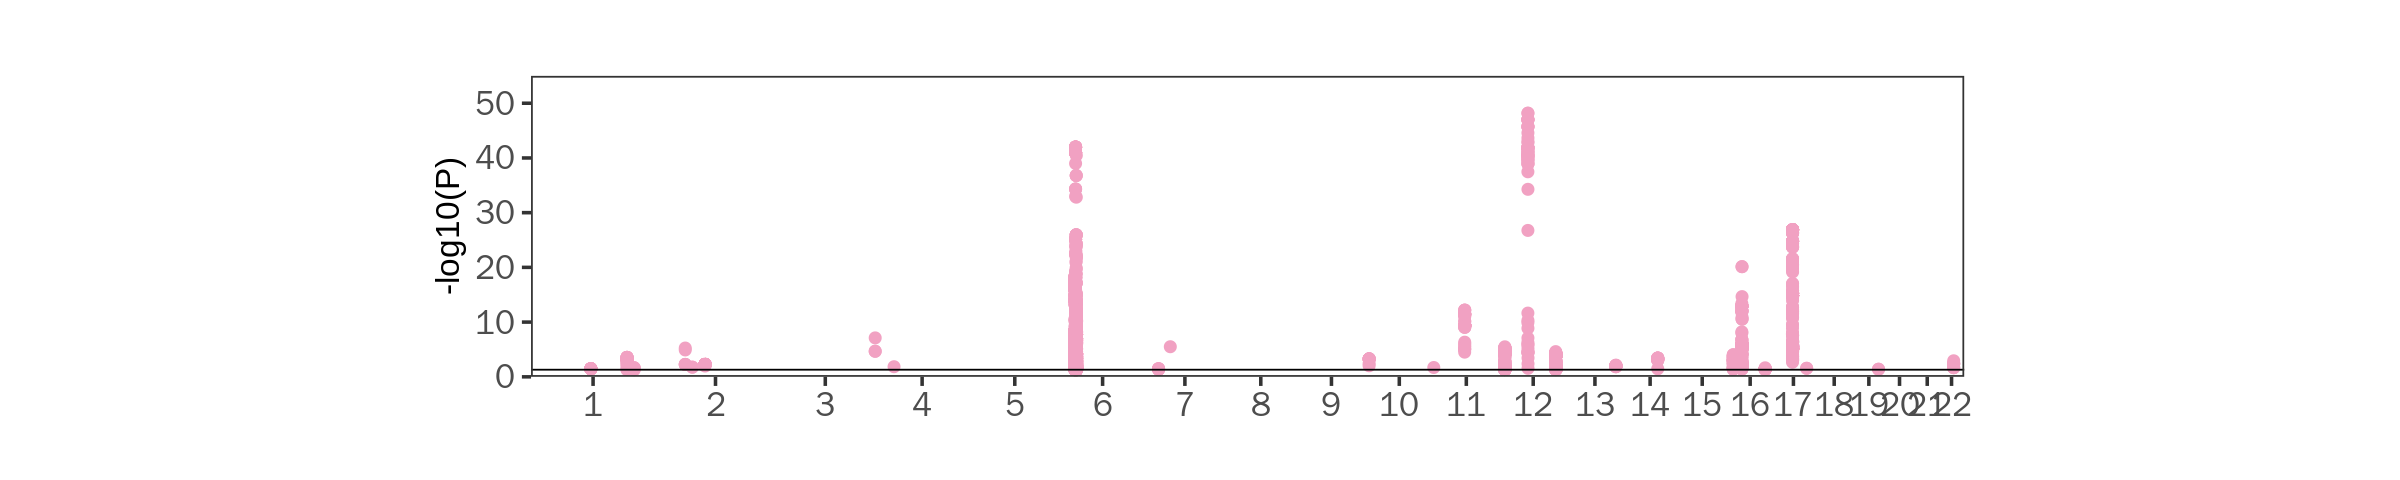

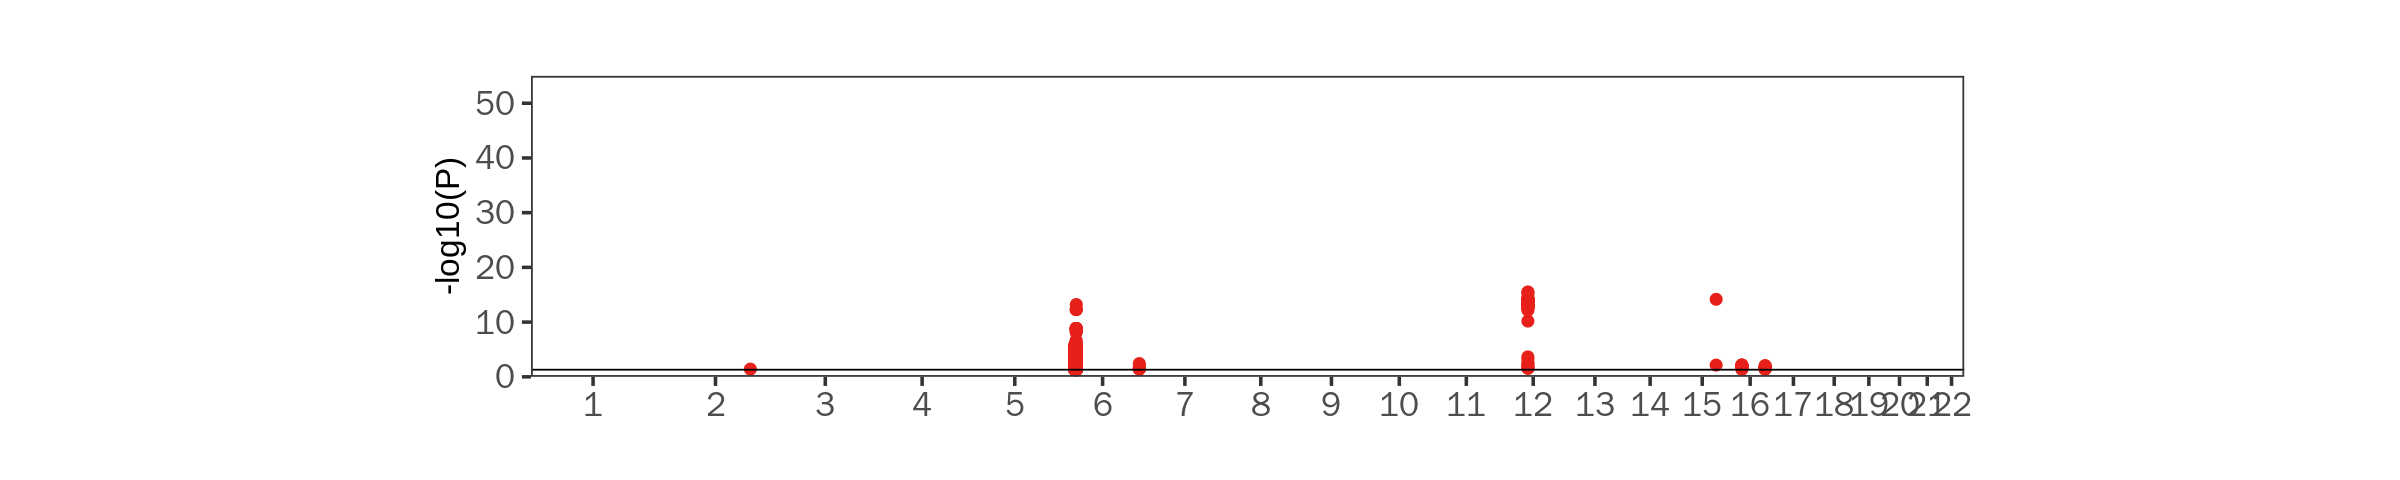

In [7]:
ct = 'B'
for (ct in cts){
df = df_all[df_all$ct == ct,]
chr=as.character(as.data.frame(str_split_fixed(df$snps, "[:_]",3))$V1)
pos=as.character(as.data.frame(str_split_fixed(df$snps, "[:_]",3))$V2)
SNP=as.character(df$snps)
TISSUE=rep('PBMC',length(SNP))
P=df$FDR
new=as.data.frame(cbind(chr,as.character(pos),P,as.character(SNP),TISSUE))
colnames(new)=c('chr','pos','P','SNP','TISSUE')
new$chr <- as.numeric(as.character(new$chr))
new$pos <- as.numeric(as.character(new$pos))
new$P <- as.numeric(as.character(new$P))
new$SNP <- as.character(new$SNP)
new$TISSUE <- as.character(new$TISSUE)
print(ct)
p=gg.manhattan(new, 0,0.05,0.01, NA, c('grey30','grey60'),c(0,55), '',color[ct])
print(p)
    }

In [8]:
geno = data.frame(fread('./input/disease_all_geno/SNP.txt'))
rownames(geno) <- geno$V1
geno = geno[2:ncol(geno)]

Warning message in fread("./input/disease_all_geno/SNP.txt"):
“检测到 163 个列名，然而数据共有 164 列（文件不合法）。添加了 1 个额外列名作为第一列，并被用于猜测行名或索引。若上述猜测不正确，可在后续使用setnames()进行修改，或修复用于生成该文件的文件写入命令以生成有效的文件。”


Warning message:
“The `size` argument of `element_line()` is deprecated as of ggplot2 3.4.0.
ℹ Please use the `linewidth` argument instead.”


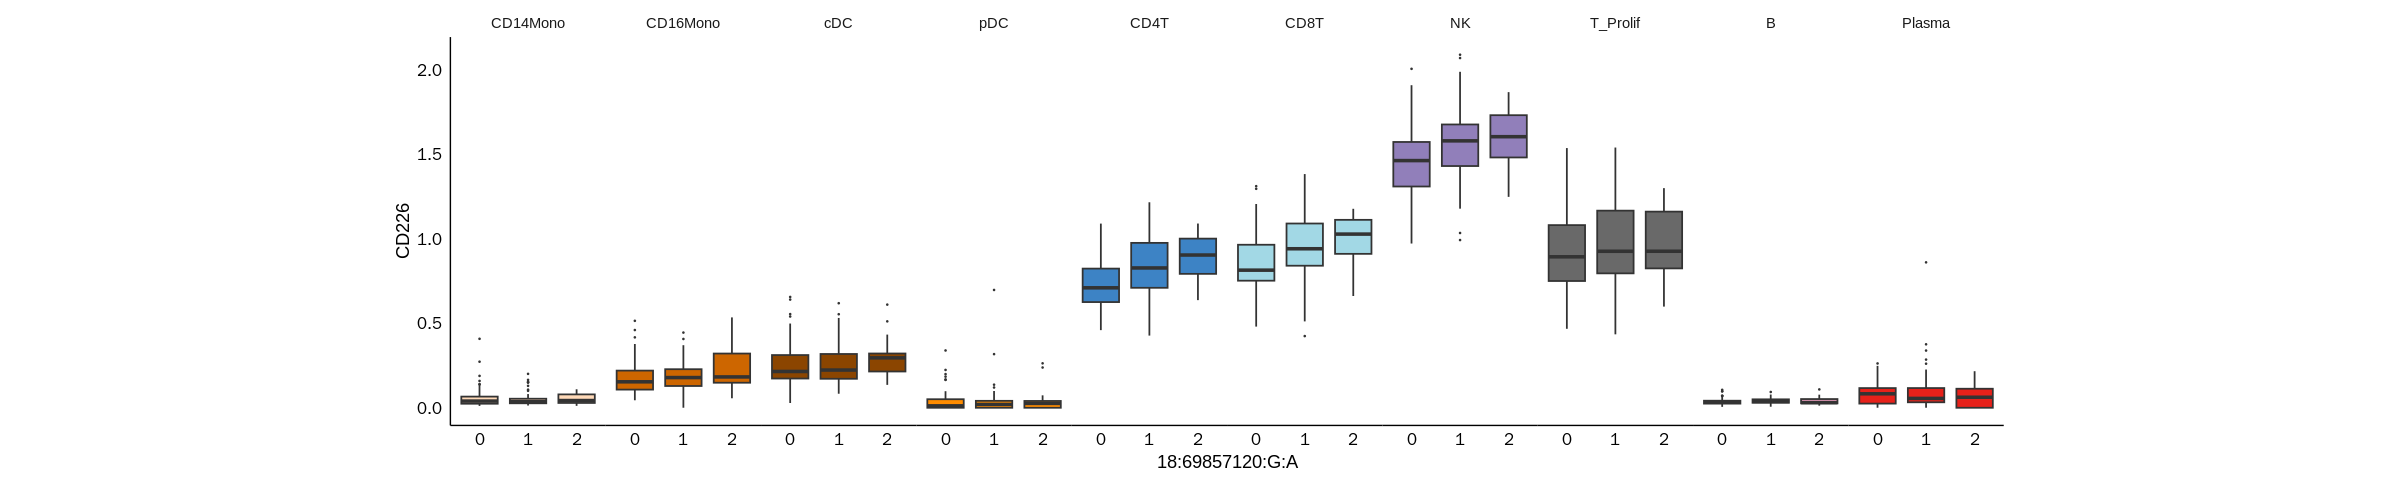

In [9]:
es = '18:69857120:G:A'
eg = 'CD226'
ed_all = data.frame()
for (ct in c('CD14Mono', 'CD16Mono', 'cDC', 'pDC','CD4T','CD8T', 'NK','T_Prolif', 'B', 'Plasma')){
    exp = read.table(paste0('./input/disease_all_geno/',ct,'_GE.txt'))
    re = intersect(colnames(geno),colnames(exp))
    ed = data.frame(t(rbind(exp[eg,re],geno[es,re])))
    colnames(ed) = c('gene','geno')
    ed$geno = as.character(ed$geno)
    ed$ct = ct
    ed_all = rbind(ed_all,ed)
    }
ed_all[is.na(ed_all)] = 0
ed_all$ct = factor(ed_all$ct,levels = c('CD14Mono', 'CD16Mono', 'cDC', 'pDC','CD4T','CD8T', 'NK','T_Prolif', 'B', 'Plasma'))
p <- ggplot(ed_all, aes(x = geno, y = gene,fill = ct)) +
  geom_boxplot(outlier.size = 0.1) +
  labs(
    x = es,
    y = eg
  ) +scale_fill_manual(values = c('#FFDAB9','#CD6600', '#8B4500', '#FF8C00','#3D83C5','#A2D8E5','#917FBA','#696969','#F1A1C2','#E7211A'))+
  #theme_bw()+
 facet_wrap(~ct, scales = 'free_x', nrow = 1)+theme_minimal()+
theme(aspect.ratio = 2.5,#plot.margin=unit(c(0.5,0.5,0.5,0.5),units=,"cm"),
        axis.line = element_line(color = "black",size = 0.4),
        #panel.grid.minor = element_blank(),
        #panel.grid.major = element_line(size = 0.2,color = "#e5e5e5"),
        axis.text.y = element_text(color="black",size=10),
        axis.text.x = element_text(margin = margin(t = 2),color="black",size=10),
        legend.position = "none",
        panel.spacing = unit(0,"lines"),
     panel.grid = element_blank())
p

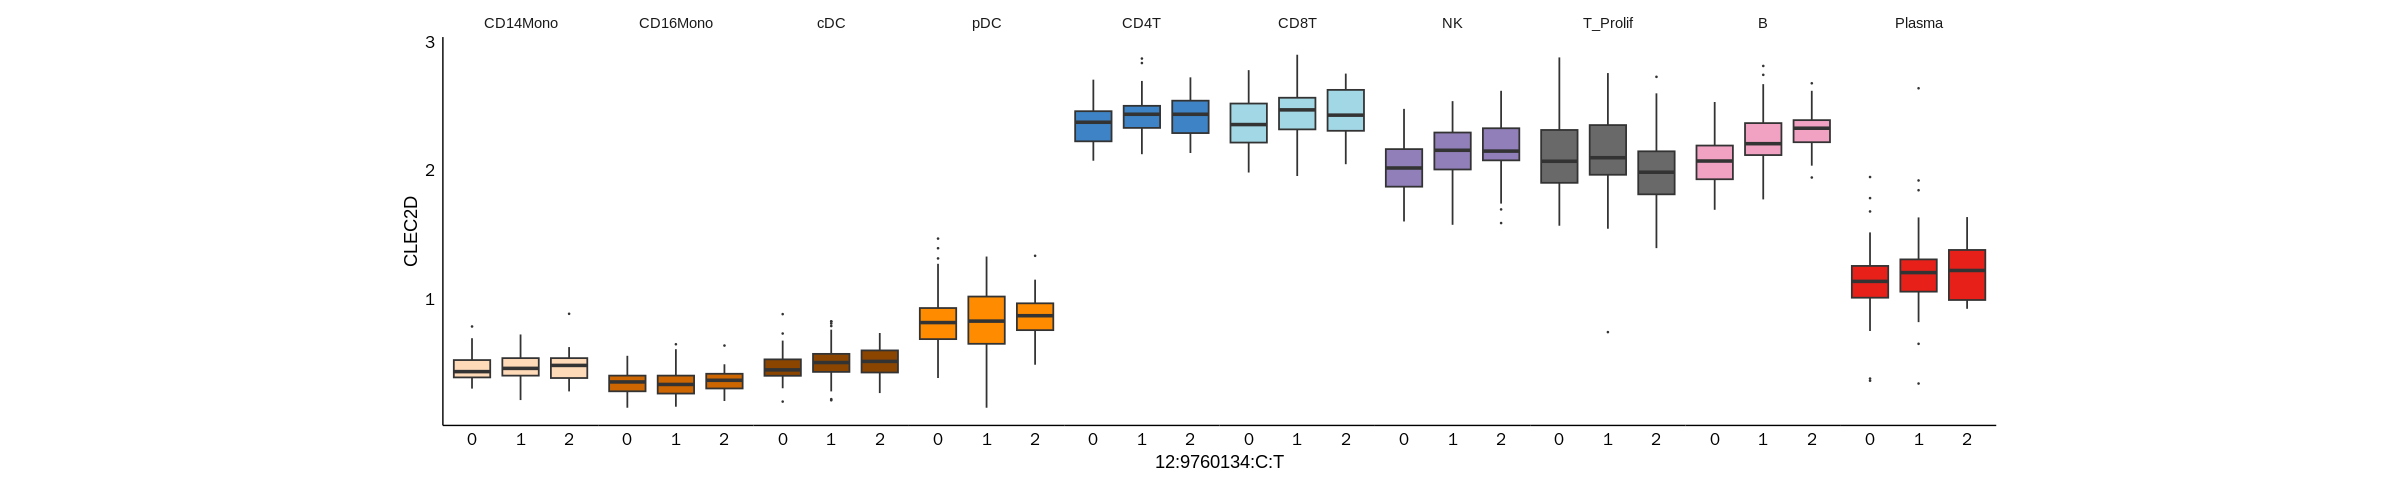

In [10]:
es = '12:9760134:C:T'
eg = 'CLEC2D'
ed_all = data.frame()
for (ct in c('CD14Mono', 'CD16Mono', 'cDC', 'pDC','CD4T','CD8T', 'NK','T_Prolif', 'B', 'Plasma')){
    exp = read.table(paste0('./input/disease_all_geno/',ct,'_GE.txt'))
    re = intersect(colnames(geno),colnames(exp))
    ed = data.frame(t(rbind(exp[eg,re],geno[es,re])))
    colnames(ed) = c('gene','geno')
    ed$geno = as.character(ed$geno)
    ed$ct = ct
    ed_all = rbind(ed_all,ed)
    }
ed_all[is.na(ed_all)] = 0
ed_all$ct = factor(ed_all$ct,levels = c('CD14Mono', 'CD16Mono', 'cDC', 'pDC','CD4T','CD8T', 'NK','T_Prolif', 'B', 'Plasma'))
p <- ggplot(ed_all, aes(x = geno, y = gene,fill = ct)) +
  geom_boxplot(outlier.size = 0.1) +
  labs(
    x = es,
    y = eg
  ) +scale_fill_manual(values = c('#FFDAB9','#CD6600', '#8B4500', '#FF8C00','#3D83C5','#A2D8E5','#917FBA','#696969','#F1A1C2','#E7211A'))+
  #theme_bw()+
 facet_wrap(~ct, scales = 'free_x', nrow = 1)+theme_minimal()+
theme(aspect.ratio = 2.5,#plot.margin=unit(c(0.5,0.5,0.5,0.5),units=,"cm"),
        axis.line = element_line(color = "black",size = 0.4),
        #panel.grid.minor = element_blank(),
        #panel.grid.major = element_line(size = 0.2,color = "#e5e5e5"),
        axis.text.y = element_text(color="black",size=10),
        axis.text.x = element_text(margin = margin(t = 2),color="black",size=10),
        legend.position = "none",
        panel.spacing = unit(0,"lines"),
     panel.grid = element_blank())
p

In [13]:
write.csv(df_all,'./res/T1D_risk_eQTL_all.csv')